In [3]:
import pandas as pd
df=pd.read_csv("Buy_Computer.csv")
print(df)

    id         age  income student credit_rating Buy_Computer
0    1       youth    high      no          fair           no
1    2       youth    high      no     excellent           no
2    3  middle_age    high      no          fair          yes
3    4      senior  medium      no          fair          yes
4    5      senior     low     yes          fair          yes
5    6      senior     low     yes     excellent           no
6    7  middle_age     low     yes     excellent          yes
7    8       youth  medium      no          fair           no
8    9       youth     low     yes          fair          yes
9   10      senior  medium     yes          fair          yes
10  11       youth  medium     yes     excellent          yes
11  12  middle_age  medium      no     excellent          yes
12  13  middle_age    high     yes          fair          yes
13  14      senior  medium      no     excellent           no


In [9]:
counts={}
count_yes=0
count_no=0
for index in df.index:
    if df["Buy_Computer"][index]=="yes":
       count_yes+=1
    else:
       count_no+=1
counts["yes"]=count_yes
counts["no"]=count_no
print(counts)

{'yes': 9, 'no': 5}


In [12]:
df=df.drop("id",axis=1)


In [13]:
print(df.head())

          age  income student credit_rating Buy_Computer
0       youth    high      no          fair           no
1       youth    high      no     excellent           no
2  middle_age    high      no          fair          yes
3      senior  medium      no          fair          yes
4      senior     low     yes          fair          yes


In [17]:
attribute_classes_probs={}
for feature in df.columns:
   if feature=="Buy_Computer":
     continue
   nominal_val_probs={}
   for idx in df.index:
     if df[feature][idx] not in nominal_val_probs:
        nominal_val_probs[df[feature][idx]]={}
        nominal_val_probs[df[feature][idx]]["yes"]=0
        nominal_val_probs[df[feature][idx]]["no"]=0
     if df["Buy_Computer"][idx]=="yes":
        nominal_val_probs[df[feature][idx]]["yes"]+=1
     else:
        nominal_val_probs[df[feature][idx]]["no"]+=1
   if feature not in attribute_classes_probs:
       attribute_classes_probs[feature]=nominal_val_probs
print(attribute_classes_probs)


{'age': {'youth': {'yes': 2, 'no': 3}, 'middle_age': {'yes': 4, 'no': 0}, 'senior': {'yes': 3, 'no': 2}}, 'income': {'high': {'yes': 2, 'no': 2}, 'medium': {'yes': 4, 'no': 2}, 'low': {'yes': 3, 'no': 1}}, 'student': {'no': {'yes': 3, 'no': 4}, 'yes': {'yes': 6, 'no': 1}}, 'credit_rating': {'fair': {'yes': 6, 'no': 2}, 'excellent': {'yes': 3, 'no': 3}}}


In [ ]:
#Bayes theorem
#age=youth , income=medium,student=yes,crediting_fair=fair
#prob(yes/(above conditions))==?

prob_yes_age_youth=attribute_classes_probs["age"]["youth"]["yes"]/(attribute_classes_probs["age"]["youth"]["yes"]+attribute_classes_probs["age"]["youth"]["no"])

## Single Layer perceptron

In [70]:
import pandas as pd
df=pd.read_csv("Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [71]:
print(df["Species"].unique())
print(df.shape)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
(150, 6)


In [72]:
df=pd.DataFrame(df)

In [73]:
df=df[df["Species"]!="Iris-virginica"]
print(df.head())
print(df.shape)

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
(100, 6)


In [74]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Species']=encoder.fit_transform(df["Species"])
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0   1            5.1           3.5            1.4           0.2        0
1   2            4.9           3.0            1.4           0.2        0
2   3            4.7           3.2            1.3           0.2        0
3   4            4.6           3.1            1.5           0.2        0
4   5            5.0           3.6            1.4           0.2        0


In [76]:
df.drop("Id",axis=1,inplace=True)
print(df.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        0
1            4.9           3.0            1.4           0.2        0
2            4.7           3.2            1.3           0.2        0
3            4.6           3.1            1.5           0.2        0
4            5.0           3.6            1.4           0.2        0


In [90]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df_scaled=df.drop("Species",axis=1)
df_scaled=scaler.fit_transform(df_scaled)
df_scaled=pd.DataFrame(df_scaled)
df_scaled["Species"]=df["Species"]
df_scaled["Species"] = df_scaled["Species"].map({0: -1, 1: 1})
print(df_scaled["Species"].value_counts())
print(df_scaled.head())

Species
-1    50
 1    50
Name: count, dtype: int64
          0         1         2         3  Species
0 -0.581066  0.857135 -1.014360 -1.038248       -1
1 -0.894309 -0.198450 -1.014360 -1.038248       -1
2 -1.207552  0.223784 -1.083741 -1.038248       -1
3 -1.364174  0.012667 -0.944978 -1.038248       -1
4 -0.737687  1.068253 -1.014360 -1.038248       -1


In [93]:
lr=0.1
bias=0.1
weights=[0.1,0.1,0.1,0.1]
def train(epochs=50):
    global bias, weights

    for epoch in range(epochs):
        update = False

        for idx in df_scaled.index:
            input1 = df_scaled[0][idx]
            input2 = df_scaled[1][idx]
            input3 = df_scaled[2][idx]
            input4 = df_scaled[3][idx]

            raw = input1*weights[0] + input2*weights[1] + input3*weights[2] + input4*weights[3] + bias
            predicted = 1 if raw >= 0 else -1
            actual = df_scaled["Species"][idx]

            if predicted != actual:
                diff = actual - predicted
                update = True

                # DIRECT UPDATE (clean)
                weights[0] += lr * diff * input1
                weights[1] += lr * diff * input2
                weights[2] += lr * diff * input3
                weights[3] += lr * diff * input4
                bias += lr * diff

        print(f"Epoch {epoch+1} completed")

        if not update:
            print("Converged!")
            break

train()

Epoch 1 completed
Epoch 2 completed
Converged!


In [94]:
print(bias)
print(weights)

-0.1
[np.float64(0.12224025830579857), np.float64(-0.24032076627425733), np.float64(0.2612429218719823), np.float64(0.23665828280335047)]


In [96]:
def accuracy():
    correct = 0

    for idx in df_scaled.index:
        x = [
            df_scaled[0][idx],
            df_scaled[1][idx],
            df_scaled[2][idx],
            df_scaled[3][idx]
        ]

        actual = df_scaled["Species"][idx]

        raw = sum(w*x_i for w, x_i in zip(weights, x)) + bias
        predicted = 1 if raw >= 0 else -1

        if predicted == actual:
            correct += 1

    acc = correct / len(df_scaled)
    print("Accuracy:", acc)
accuracy()

Accuracy: 1.0


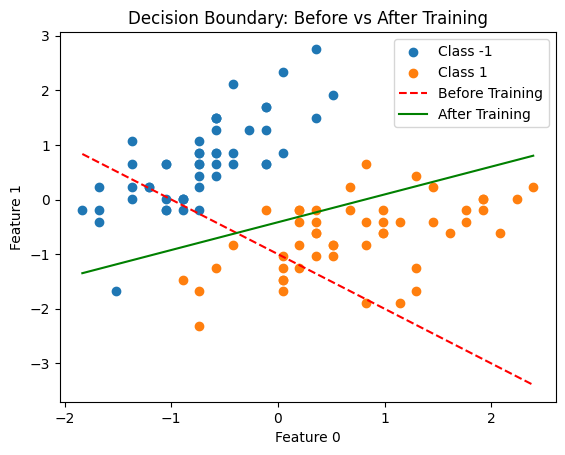

In [98]:
import matplotlib.pyplot as plt
import numpy as np

def plot_before_after():
    plt.figure()
    for label in [-1, 1]:
        subset = df_scaled[df_scaled["Species"] == label]
        plt.scatter(subset[0], subset[1], label=f"Class {label}")

    x1 = np.linspace(df_scaled[0].min(), df_scaled[0].max(), 100)

    # BEFORE training
    w_before = [0.1, 0.1]
    b_before = 0.1
    x2_before = -(w_before[0]*x1 + b_before) / w_before[1]
    plt.plot(x1, x2_before, 'r--', label="Before Training")

    # AFTER training (using learned values)
    w_after = [0.12224025830579857, -0.24032076627425733]
    b_after = -0.1
    x2_after = -(w_after[0]*x1 + b_after) / w_after[1]
    plt.plot(x1, x2_after, 'g-', label="After Training")

    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.title("Decision Boundary: Before vs After Training")
    plt.legend()
    plt.show()
plot_before_after()

## MLP And Backpropagation

In [99]:
import pandas as pd
df=pd.read_csv("Iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [100]:
print(df["Species"].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [101]:
def get_target(label):
    if label=="Iris-setosa":
       return [1,0,0]
    elif label=="Iris-versicolor":
       return [0,1,0]
    else:
       return [0,0,1]
features=["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm"]
#normalize
for col in features:
    curr_mean=df[col].mean()
    curr_std=df[col].std()
    df[col]=(df[col]-curr_mean)/curr_std

In [102]:
#initialize weights and biases
bias_hidden=[0.1,0.1,0.1]
bias_output=[0.1,0.1,0.1]

weights_hidden=[[0.1,0.1,0.1,0.1],
                [0.1,0.1,0.1,0.1],
                [0.1,0.1,0.1,0.1]]
weights_output=[[0.1,0.1,0.1],
                [0.1,0.1,0.1],
                [0.1,0.1,0.1]]
lr=0.1
losses=[]
epochs=100


In [103]:
import math
def sigmoid(x):
    return 1/(1+math.exp(-x))

In [106]:
losses=[]
for epoch in range(epochs):
    total_losses=0
    for i in df.index:
        inputs = [
            df["SepalLengthCm"][i],
            df["SepalWidthCm"][i],
            df["PetalLengthCm"][i],
            df["PetalWidthCm"][i]
        ]

        # forward
        hidden=[]
        for j in range(3):
           s=0
           for k in range(4):
              s+=inputs[k]*weights_hidden[j][k]
           s+=bias_hidden[j]
           hidden.append(sigmoid(s))
        output=[]
        for j in range(3):
           s=0
           for k in range(3):
              s+=hidden[k]*weights_output[j][k]
           s+=bias_output[j]
           output.append(sigmoid(s))
        actual=get_target(df["Species"][i])
        loss=0
        for j in range(3):
           loss+=(actual[j]-output[j])**2
        total_losses+=loss

        # Backpropagation
        d_output=[]
        for j in range(3):
           d=(output[j]-actual[j])*output[j]*(1-output[j])
           d_output.append(d)

        for j in range(3):
           for k in range(3):
             weights_output[j][k]-=lr*d_output[j]*hidden[k]
           bias_output[j]-=lr*d_output[j]


        for j in range(3):
           d_hidden=0
           for k in range(3):
              d_hidden=d_output[k]*weights_output[j][k]
           d_hidden=d_hidden*hidden[j]*(1-hidden[j])
           for k in range(4):
              weights_hidden[j][k]-=lr*d_hidden*inputs[k]
           bias_hidden[j]-=lr*d_hidden
    print(f"epoch:{epoch},loss:{total_losses}")
    losses.append(total_losses)

epoch:0,loss:20.135823201471492
epoch:1,loss:19.92816558407707
epoch:2,loss:19.724110773304513
epoch:3,loss:19.523608851949707
epoch:4,loss:19.326609003965437
epoch:5,loss:19.133059663114572
epoch:6,loss:18.942908651907842
epoch:7,loss:18.75610331116122
epoch:8,loss:18.572590620527382
epoch:9,loss:18.392317310368675
epoch:10,loss:18.21522996534918
epoch:11,loss:18.041275120126308
epoch:12,loss:17.870399347525236
epoch:13,loss:17.702549339576283
epoch:14,loss:17.53767198179203
epoch:15,loss:17.375714421053196
epoch:16,loss:17.21662412746489
epoch:17,loss:17.060348950534905
epoch:18,loss:16.906837170014384
epoch:19,loss:16.756037541730446
epoch:20,loss:16.607899338726423
epoch:21,loss:16.462372388014774
epoch:22,loss:16.319407103232667
epoch:23,loss:16.178954513477322
epoch:24,loss:16.040966288586645
epoch:25,loss:15.905394761115565
epoch:26,loss:15.772192945246301
epoch:27,loss:15.641314552858546
epoch:28,loss:15.512714006972441
epoch:29,loss:15.386346452765453
epoch:30,loss:15.26216776

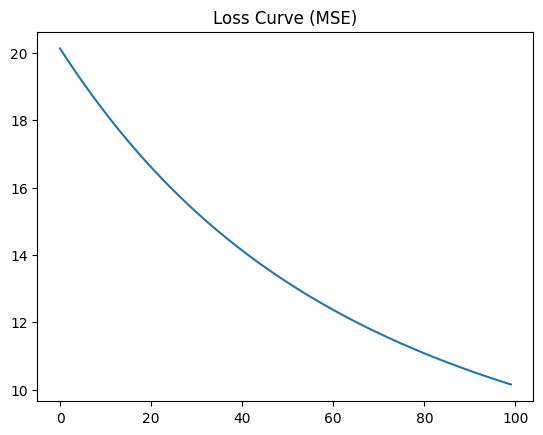

In [107]:
plt.plot(losses)
plt.title("Loss Curve (MSE)")
plt.show()

In [114]:
correct=0
for i in df.index:
    inputs = [
            df["SepalLengthCm"][i],
            df["SepalWidthCm"][i],
            df["PetalLengthCm"][i],
            df["PetalWidthCm"][i]
        ]

        # forward
    hidden=[]
    for j in range(3):
       s=0
       for k in range(4):
          s+=inputs[k]*weights_hidden[j][k]
       s+=bias_hidden[j]
       hidden.append(sigmoid(s))
    output=[]
    for j in range(3):
           s=0
           for k in range(3):
              s+=hidden[k]*weights_output[j][k]
           s+=bias_output[j]
           output.append(sigmoid(s))
    actual=get_target(df["Species"][i])
    pred=output.index(max(output))
    actual=actual.index(max(actual))
    if actual==pred:
      correct+=1
print("accuracy:",correct/len(df))

accuracy: 0.98
